<a href="https://colab.research.google.com/github/vemulasailahith/Customer_Churn_Prediction_System/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("/telco.csv")
# Display the first 5 rows of the dataset
# This helps us understand the structure and type of data
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Display the number of rows and columns in the dataset
# Output will be in the form: (rows, columns)
df.shape

(7043, 50)

In [ ]:
for i, column in enumerate(df.columns, 1):
    print(i, column)

1 Customer ID
2 Gender
3 Age
4 Under 30
5 Senior Citizen
6 Married
7 Dependents
8 Number of Dependents
9 Country
10 State
11 City
12 Zip Code
13 Latitude
14 Longitude
15 Population
16 Quarter
17 Referred a Friend
18 Number of Referrals
19 Tenure in Months
20 Offer
21 Phone Service
22 Avg Monthly Long Distance Charges
23 Multiple Lines
24 Internet Service
25 Internet Type
26 Avg Monthly GB Download
27 Online Security
28 Online Backup
29 Device Protection Plan
30 Premium Tech Support
31 Streaming TV
32 Streaming Movies
33 Streaming Music
34 Unlimited Data
35 Contract
36 Paperless Billing
37 Payment Method
38 Monthly Charge
39 Total Charges
40 Total Refunds
41 Total Extra Data Charges
42 Total Long Distance Charges
43 Total Revenue
44 Satisfaction Score
45 Customer Status
46 Churn Label
47 Churn Score
48 CLTV
49 Churn Category
50 Churn Reason


In [ ]:
# Display information about the dataset
# It shows column names, data types, and number of non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [ ]:
# Count the number of missing values in each column
df.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
Under 30,0
Senior Citizen,0
Married,0
Dependents,0
Number of Dependents,0
Country,0
State,0


In [ ]:
# Filter and display only columns having missing values
df.isnull().sum()[df.isnull().sum() > 0]

,0
Offer,3877
Internet Type,1526
Churn Category,5174
Churn Reason,5174


In [ ]:
# Filter and display only columns having missing values
df.isnull().sum()[df.isnull().sum() > 0]

,0
Offer,3877
Internet Type,1526
Churn Category,5174
Churn Reason,5174


In [ ]:
# Display the different values present in the Churn Label column
df["Churn Label"].value_counts()

,count
Churn Label,
No,5174
Yes,1869


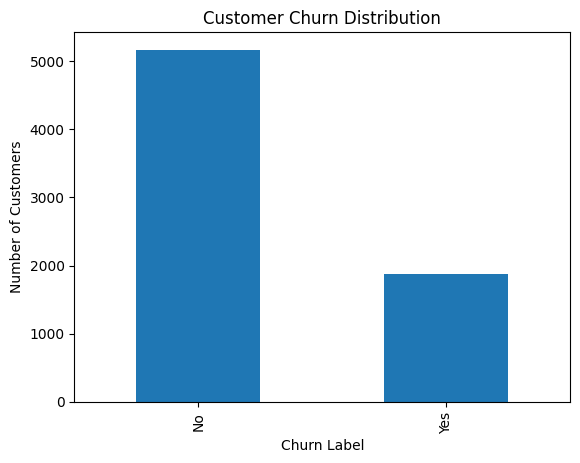

In [ ]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Count the number of customers in each churn category
churn_counts = df["Churn Label"].value_counts()

# Create a bar chart
churn_counts.plot(kind="bar")

# Add title and axis labels
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Label")
plt.ylabel("Number of Customers")

# Display the graph
plt.show()

In [ ]:
# Display statistical information for numerical columns
# Includes count, mean, standard deviation, minimum, maximum, etc.
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


In [ ]:
# Select columns containing categorical/text data
categorical_columns = df.select_dtypes(include=["object"]).columns

# Display the categorical column names
categorical_columns.tolist()

['Customer ID',
 'Gender',
 'Under 30',
 'Senior Citizen',
 'Married',
 'Dependents',
 'Country',
 'State',
 'City',
 'Quarter',
 'Referred a Friend',
 'Offer',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Internet Type',
 'Online Security',
 'Online Backup',
 'Device Protection Plan',
 'Premium Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Streaming Music',
 'Unlimited Data',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Customer Status',
 'Churn Label',
 'Churn Category',
 'Churn Reason']

In [ ]:
# Select columns containing numerical data
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

# Display the numerical column names
numerical_columns.tolist()

['Age',
 'Number of Dependents',
 'Zip Code',
 'Latitude',
 'Longitude',
 'Population',
 'Number of Referrals',
 'Tenure in Months',
 'Avg Monthly Long Distance Charges',
 'Avg Monthly GB Download',
 'Monthly Charge',
 'Total Charges',
 'Total Refunds',
 'Total Extra Data Charges',
 'Total Long Distance Charges',
 'Total Revenue',
 'Satisfaction Score',
 'Churn Score',
 'CLTV']

In [ ]:
# Create a list of columns that should not be used for churn prediction
# These columns either identify the customer or contain post-churn information
columns_to_drop = [
    "Customer ID",
    "Customer Status",
    "Churn Score",
    "Churn Category",
    "Churn Reason"
]

# Remove these columns from the dataset
df_model = df.drop(columns=columns_to_drop)

# Display the remaining columns
df_model.columns.tolist()

['Gender',
 'Age',
 'Under 30',
 'Senior Citizen',
 'Married',
 'Dependents',
 'Number of Dependents',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Latitude',
 'Longitude',
 'Population',
 'Quarter',
 'Referred a Friend',
 'Number of Referrals',
 'Tenure in Months',
 'Offer',
 'Phone Service',
 'Avg Monthly Long Distance Charges',
 'Multiple Lines',
 'Internet Service',
 'Internet Type',
 'Avg Monthly GB Download',
 'Online Security',
 'Online Backup',
 'Device Protection Plan',
 'Premium Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Streaming Music',
 'Unlimited Data',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charge',
 'Total Charges',
 'Total Refunds',
 'Total Extra Data Charges',
 'Total Long Distance Charges',
 'Total Revenue',
 'Satisfaction Score',
 'Churn Label',
 'CLTV']

In [ ]:
# X contains the input features used by the machine learning model
X = df_model.drop(columns=["Churn Label"])

# y contains the target variable that we want to predict
y = df_model["Churn Label"]

# Display the dimensions of X and y
print("Features:", X.shape)
print("Target:", y.shape)

Features: (7043, 44)
Target: (7043,)


In [ ]:
# Convert the churn labels into numerical values
# Yes = 1 means customer churned
# No  = 0 means customer did not churn
y = y.map({"Yes": 1, "No": 0})

# Check the converted values
y.value_counts()

,count
Churn Label,
0,5174
1,1869


In [ ]:
# Display the data type of every feature
X.dtypes

,0
Gender,object
Age,int64
Under 30,object
Senior Citizen,object
Married,object
Dependents,object
Number of Dependents,int64
Country,object
State,object
City,object


In [ ]:
# Check whether any missing values are present in our features
X.isnull().sum()

,0
Gender,0
Age,0
Under 30,0
Senior Citizen,0
Married,0
Dependents,0
Number of Dependents,0
Country,0
State,0
City,0


In [ ]:
# Display the first 5 rows of the features
X.head()

,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,City,...,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,CLTV
0,Male,78,No,Yes,No,No,0,United States,California,Los Angeles,...,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65,3,5433
1,Female,74,No,Yes,Yes,Yes,1,United States,California,Los Angeles,...,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10,3,5302
2,Male,71,No,Yes,No,Yes,3,United States,California,Los Angeles,...,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,2,3179
3,Female,78,No,Yes,Yes,Yes,1,United States,California,Inglewood,...,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07,2,5337
4,Female,80,No,Yes,Yes,Yes,1,United States,California,Whittier,...,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36,2,2793


In [ ]:
# Check the values and their frequencies in the Offer column
df["Offer"].value_counts(dropna=False)

,count
Offer,
NaN,3877
Offer B,824
Offer E,805
Offer D,602
Offer A,520
Offer C,415


In [ ]:
# Check the values and their frequencies in the Internet Type column
df["Internet Type"].value_counts(dropna=False)

,count
Internet Type,
Fiber Optic,3035
DSL,1652
NaN,1526
Cable,830


In [ ]:
# Check Internet Service against Internet Type
pd.crosstab(
    df["Internet Service"],
    df["Internet Type"],
    dropna=False
)

Internet Type,Cable,DSL,Fiber Optic,NaN
Internet Service,,,,
No,0,0,0,1526
Yes,830,1652,3035,0


In [ ]:
# Replace missing Offer values with "No Offer"
# This represents customers who were not given an offer
X["Offer"] = X["Offer"].fillna("No Offer")

In [ ]:
# Replace missing Internet Type values with "No Internet"
# Missing values occur because these customers do not have internet service
X["Internet Type"] = X["Internet Type"].fillna("No Internet")

In [ ]:
# Check the number of missing values after handling them
X.isnull().sum()

,0
Gender,0
Age,0
Under 30,0
Senior Citizen,0
Married,0
Dependents,0
Number of Dependents,0
Country,0
State,0
City,0


In [ ]:
# Find all categorical columns in our feature dataset
categorical_columns = X.select_dtypes(include=["object"]).columns

# Display their names
print("Categorical Features:")
for column in categorical_columns:
    print(column)

Categorical Features:
Gender
Under 30
Senior Citizen
Married
Dependents
Country
State
City
Quarter
Referred a Friend
Offer
Phone Service
Multiple Lines
Internet Service
Internet Type
Online Security
Online Backup
Device Protection Plan
Premium Tech Support
Streaming TV
Streaming Movies
Streaming Music
Unlimited Data
Contract
Paperless Billing
Payment Method


In [ ]:
# Display the number of unique values in every feature
for column in X.columns:
    print(column, ":", X[column].nunique())

Gender : 2
Age : 62
Under 30 : 2
Senior Citizen : 2
Married : 2
Dependents : 2
Number of Dependents : 10
Country : 1
State : 1
City : 1106
Zip Code : 1626
Latitude : 1626
Longitude : 1625
Population : 1569
Quarter : 1
Referred a Friend : 2
Number of Referrals : 12
Tenure in Months : 72
Offer : 6
Phone Service : 2
Avg Monthly Long Distance Charges : 3584
Multiple Lines : 2
Internet Service : 2
Internet Type : 4
Avg Monthly GB Download : 50
Online Security : 2
Online Backup : 2
Device Protection Plan : 2
Premium Tech Support : 2
Streaming TV : 2
Streaming Movies : 2
Streaming Music : 2
Unlimited Data : 2
Contract : 3
Paperless Billing : 2
Payment Method : 3
Monthly Charge : 1585
Total Charges : 6540
Total Refunds : 500
Total Extra Data Charges : 16
Total Long Distance Charges : 6087
Total Revenue : 6982
Satisfaction Score : 5
CLTV : 3438


In [ ]:
# Display the current columns in X
print("Number of columns:", len(X.columns))
print(X.columns.tolist())

Number of columns: 44
['Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Country', 'State', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'CLTV']


In [ ]:
# Columns that we don't need for the churn prediction model
columns_to_remove = [
    "Country",
    "State",
    "City",
    "Zip Code",
    "Latitude",
    "Longitude",
    "Quarter"
]

# Remove only columns that currently exist in X
X = X.drop(
    columns=[col for col in columns_to_remove if col in X.columns]
)

# Display the new shape
print("Features after selection:", X.shape)

Features after selection: (7043, 37)


In [ ]:
# Identify categorical features such as Gender, Contract, Payment Method, etc.
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

# Identify numerical features such as Age, Tenure, Monthly Charge, etc.
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Display categorical features
print("Categorical Features:")
for column in categorical_features:
    print(column)

# Display numerical features
print("\nNumerical Features:")
for column in numerical_features:
    print(column)

# Display the total number of each type
print("\nTotal Categorical Features:", len(categorical_features))
print("Total Numerical Features:", len(numerical_features))

Categorical Features:
Gender
Under 30
Senior Citizen
Married
Dependents
Referred a Friend
Offer
Phone Service
Multiple Lines
Internet Service
Internet Type
Online Security
Online Backup
Device Protection Plan
Premium Tech Support
Streaming TV
Streaming Movies
Streaming Music
Unlimited Data
Contract
Paperless Billing
Payment Method

Numerical Features:
Age
Number of Dependents
Population
Number of Referrals
Tenure in Months
Avg Monthly Long Distance Charges
Avg Monthly GB Download
Monthly Charge
Total Charges
Total Refunds
Total Extra Data Charges
Total Long Distance Charges
Total Revenue
Satisfaction Score
CLTV

Total Categorical Features: 22
Total Numerical Features: 15


In [ ]:
# Import tools required for preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Apply StandardScaler to numerical features
# This brings numerical values to a similar scale
numerical_transformer = StandardScaler()

# Convert categorical values into numerical columns
# handle_unknown="ignore" prevents errors when a new category
# appears in the test data
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

# Combine both preprocessing methods
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% of the data is used for training
# 20% of the data is used for testing
# stratify=y keeps the same proportion of churned/non-churned
# customers in both datasets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the dimensions of each dataset
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5634, 37)
Testing features: (1409, 37)
Training target: (5634,)
Testing target: (1409,)


In [ ]:
# Fit the preprocessing pipeline using only training data
# and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the testing data using the rules learned from training data
X_test_processed = preprocessor.transform(X_test)

# Display the processed data dimensions
print("Training data after preprocessing:", X_train_processed.shape)
print("Testing data after preprocessing:", X_test_processed.shape)

Training data after preprocessing: (5634, 67)
Testing data after preprocessing: (1409, 67)


In [ ]:
#Model Selection Based On Performance

In [ ]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
# max_iter is increased so the model has enough iterations to converge
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model using the processed training data
logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Make predictions on the test data
y_pred = logistic_model.predict(X_test_processed)

# Calculate the probability of churn
y_probability = logistic_model.predict_proba(X_test_processed)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probability)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Logistic Regression Performance
--------------------------------
Accuracy : 0.961
Precision: 0.9518
Recall   : 0.8984
F1-Score : 0.9243
ROC-AUC  : 0.9921


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model using the processed training data
decision_tree_model.fit(
    X_train_processed,
    y_train
)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [ ]:
# Predict churn for the test data
dt_pred = decision_tree_model.predict(X_test_processed)

# Calculate churn probabilities
dt_probability = decision_tree_model.predict_proba(
    X_test_processed
)[:, 1]

print("Decision Tree predictions completed!")

Decision Tree predictions completed!


In [ ]:
# Calculate Decision Tree performance
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_roc_auc = roc_auc_score(y_test, dt_probability)

print("Decision Tree Performance")
print("-------------------------")
print("Accuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1-Score :", round(dt_f1, 4))
print("ROC-AUC  :", round(dt_roc_auc, 4))

Decision Tree Performance
-------------------------
Accuracy : 0.9475
Precision: 0.9011
Recall   : 0.9011
F1-Score : 0.9011
ROC-AUC  : 0.9327


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model using the processed training data
random_forest_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
# Predict churn for the test dataset
rf_pred = random_forest_model.predict(X_test_processed)

# Calculate churn probabilities
rf_probability = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]

print("Random Forest predictions completed!")

Random Forest predictions completed!


In [ ]:
# Calculate Random Forest performance
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_probability)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))

Random Forest Performance
-------------------------
Accuracy : 0.9595
Precision: 0.9703
Recall   : 0.8743
F1-Score : 0.9198
ROC-AUC  : 0.9837


In [ ]:
# Import the K-Nearest Neighbors classifier
from sklearn.neighbors import KNeighborsClassifier

# Create the KNN model
# n_neighbors=5 means the model looks at the 5 nearest customers
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

# Train the KNN model using the preprocessed training data
knn_model.fit(
    X_train_processed,
    y_train
)

# Display a confirmation message
print("KNN model trained successfully!")

KNN model trained successfully!


In [ ]:
# Make predictions for the test data
knn_pred = knn_model.predict(X_test_processed)

# Get the probability of the customer belonging to the "Churn = Yes" class
# [:, 1] selects the probability for class 1 (Churn)
knn_probability = knn_model.predict_proba(
    X_test_processed
)[:, 1]

# Display a confirmation message
print("KNN predictions completed!")

KNN predictions completed!


In [ ]:
# Calculate Accuracy
knn_accuracy = accuracy_score(y_test, knn_pred)

# Calculate Precision
knn_precision = precision_score(y_test, knn_pred)

# Calculate Recall
knn_recall = recall_score(y_test, knn_pred)

# Calculate F1-Score
knn_f1 = f1_score(y_test, knn_pred)

# Calculate ROC-AUC
knn_roc_auc = roc_auc_score(y_test, knn_probability)

# Display KNN performance
print("KNN Performance")
print("----------------")
print("Accuracy :", round(knn_accuracy, 4))
print("Precision:", round(knn_precision, 4))
print("Recall   :", round(knn_recall, 4))
print("F1-Score :", round(knn_f1, 4))
print("ROC-AUC  :", round(knn_roc_auc, 4))

KNN Performance
----------------
Accuracy : 0.9241
Precision: 0.8847
Recall   : 0.8209
F1-Score : 0.8516
ROC-AUC  : 0.9626


In [ ]:
# | Algorithm               |   Accuracy |  Precision |     Recall |   F1-Score |    ROC-AUC |
# | ----------------------- | ---------: | ---------: | ---------: | ---------: | ---------: |
# | **Logistic Regression** | **96.10%** |     95.18% |     89.84% | **92.43%** | **99.21%** |
# | Decision Tree           |     94.75% |     90.11% | **90.11%** |     90.11% |     93.27% |
# | Random Forest           |     95.95% | **97.03%** |     87.43% |     91.98% |     98.37% |
# | KNN                     |     92.41% |     88.47% |     82.09% |     85.16% |     96.26% |


In [ ]:
#Customer Segmentation Part

In [ ]:

# Select numerical features for customer segmentation
# These features describe customer behavior, usage, satisfaction,
# spending, and relationship with the company.

segmentation_features = [
    "Age",
    "Number of Dependents",
    "Number of Referrals",
    "Tenure in Months",
    "Avg Monthly Long Distance Charges",
    "Avg Monthly GB Download",
    "Monthly Charge",
    "Total Charges",
    "Total Revenue",
    "Satisfaction Score",
    "CLTV"
]

# Create a new dataset containing only these features
X_segmentation = X[segmentation_features]

# Display the shape of the segmentation dataset
print("Segmentation data shape:", X_segmentation.shape)

# Display the first five rows
X_segmentation.head()

Segmentation data shape: (7043, 11)


,Age,Number of Dependents,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Revenue,Satisfaction Score,CLTV
0,78,0,0,1,0.00,8,39.65,39.65,59.65,3,5433
1,74,1,1,8,48.85,17,80.65,633.30,1024.10,3,5302
2,71,3,0,18,11.33,52,95.45,1752.55,1910.88,2,3179
3,78,1,1,25,19.76,12,98.50,2514.50,2995.07,2,5337
4,80,1,1,37,6.33,14,76.50,2868.15,3102.36,2,2793


In [ ]:
# Import StandardScaler
# It converts all features to a common scale.
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on our segmentation data
# and transform the values into standardized values.
X_segmentation_scaled = scaler.fit_transform(
    X_segmentation
)

# Display the shape of the scaled data
print(
    "Scaled segmentation data shape:",
    X_segmentation_scaled.shape
)

Scaled segmentation data shape: (7043, 11)


In [ ]:
# Import KMeans
from sklearn.cluster import KMeans

# Store the inertia values for different numbers of clusters
inertia_values = []

# Test different values of K from 2 to 10
for k in range(2, 11):

    # Create a K-Means model with the current number of clusters
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Train the K-Means model
    kmeans.fit(X_segmentation_scaled)

    # Store the inertia value
    inertia_values.append(kmeans.inertia_)

# Display the inertia values
for k, inertia in zip(range(2, 11), inertia_values):
    print("K =", k, "| Inertia =", round(inertia, 2))

K = 2 | Inertia = 59297.76
K = 3 | Inertia = 52678.61
K = 4 | Inertia = 48266.93
K = 5 | Inertia = 45172.46
K = 6 | Inertia = 42768.31
K = 7 | Inertia = 40702.8
K = 8 | Inertia = 38931.16
K = 9 | Inertia = 37553.56
K = 10 | Inertia = 36250.01


In [ ]:
# Import the silhouette score function
from sklearn.metrics import silhouette_score

# Store silhouette scores for different values of K
silhouette_values = []

# Test K values from 2 to 10
for k in range(2, 11):

    # Create the K-Means model
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Create cluster assignments for each customer
    cluster_labels = kmeans.fit_predict(
        X_segmentation_scaled
    )

    # Calculate how well the clusters are separated
    score = silhouette_score(
        X_segmentation_scaled,
        cluster_labels
    )

    # Store the score
    silhouette_values.append(score)

# Display the scores
for k, score in zip(range(2, 11), silhouette_values):
    print(
        "K =", k,
        "| Silhouette Score =", round(score, 4)
    )

K = 2 | Silhouette Score = 0.2347
K = 3 | Silhouette Score = 0.174
K = 4 | Silhouette Score = 0.1756
K = 5 | Silhouette Score = 0.1644
K = 6 | Silhouette Score = 0.1535
K = 7 | Silhouette Score = 0.1503
K = 8 | Silhouette Score = 0.1461
K = 9 | Silhouette Score = 0.1413
K = 10 | Silhouette Score = 0.1348


In [ ]:
# Selected K=2

In [ ]:
# Create the final K-Means model
# We selected K = 2 based on the highest Silhouette Score.
final_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# Train the model and assign each customer to a cluster
cluster_labels = final_kmeans.fit_predict(
    X_segmentation_scaled
)

# Display a confirmation message
print("Final K-Means model trained successfully!")

# Display the number of customers in each cluster
print("\nCustomers in each cluster:")
print(pd.Series(cluster_labels).value_counts().sort_index())

Final K-Means model trained successfully!

Customers in each cluster:
0    4799
1    2244
Name: count, dtype: int64


In [ ]:
# Create a copy of the original segmentation data
# so that we can add the cluster labels to it.
segmentation_results = X_segmentation.copy()

# Add the cluster assigned by K-Means
segmentation_results["Cluster"] = cluster_labels

# Calculate the average value of every feature
# for each customer cluster.
cluster_profile = segmentation_results.groupby(
    "Cluster"
).mean()

# Display the cluster profiles
print("Customer Segment Profiles:")
display(cluster_profile.round(2))

Customer Segment Profiles:


,Age,Number of Dependents,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Revenue,Satisfaction Score,CLTV
Cluster,,,,,,,,,,,
0,46.16,0.44,1.41,20.31,21.90,17.16,53.41,931.89,1359.67,3.19,4114.75
1,47.26,0.52,3.12,58.21,25.22,27.69,89.04,5164.25,6615.90,3.37,5010.96


In [ ]:
# We shouldn't conclude that Cluster 1 is "loyal" solely because it has longer tenure. It has characteristics associated with valuable, established customers, but we haven't yet checked their actual churn rates.

# And that's actually a very useful next analysis:

# How does churn differ between Cluster 0 and Cluster 1?

# This will connect your K-Means segmentation with your churn prediction

In [ ]:
# Create a copy of the model dataset
# so that we don't change the original data.
cluster_churn_analysis = df_model.copy()

# Add the K-Means cluster assigned to each customer
cluster_churn_analysis["Cluster"] = cluster_labels

# Convert Churn Label from Yes/No to 1/0
# 1 = Customer churned
# 0 = Customer did not churn
cluster_churn_analysis["Churn_Numeric"] = (
    cluster_churn_analysis["Churn Label"]
    .map({"Yes": 1, "No": 0})
)

# Calculate the number of customers and average churn
# for each cluster.
cluster_churn_summary = cluster_churn_analysis.groupby(
    "Cluster"
).agg(
    Customers=("Churn_Numeric", "count"),
    Churn_Rate=("Churn_Numeric", "mean")
)

# Convert the churn rate from decimal to percentage
cluster_churn_summary["Churn_Rate"] = (
    cluster_churn_summary["Churn_Rate"] * 100
)

# Display the final result
print("Churn Rate by Customer Segment:")
display(cluster_churn_summary.round(2))

Churn Rate by Customer Segment:


,Customers,Churn_Rate
Cluster,,
0,4799,32.22
1,2244,14.39


In [ ]:
# Model Performance Comparison

In [ ]:
# Import pandas
import pandas as pd

# Create a table containing the performance
# of all four classification models.
model_comparison = pd.DataFrame({
    "Algorithm": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],

    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy,
        knn_accuracy
    ],

    "Precision": [
        precision,
        dt_precision,
        rf_precision,
        knn_precision
    ],

    "Recall": [
        recall,
        dt_recall,
        rf_recall,
        knn_recall
    ],

    "F1-Score": [
        f1,
        dt_f1,
        rf_f1,
        knn_f1
    ],

    "ROC-AUC": [
        roc_auc,
        dt_roc_auc,
        rf_roc_auc,
        knn_roc_auc
    ]
})

# Display the comparison table
display(model_comparison.round(4))

,Algorithm,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9610,0.9518,0.8984,0.9243,0.9921
1,Decision Tree,0.9475,0.9011,0.9011,0.9011,0.9327
2,Random Forest,0.9595,0.9703,0.8743,0.9198,0.9837
3,KNN,0.9241,0.8847,0.8209,0.8516,0.9626


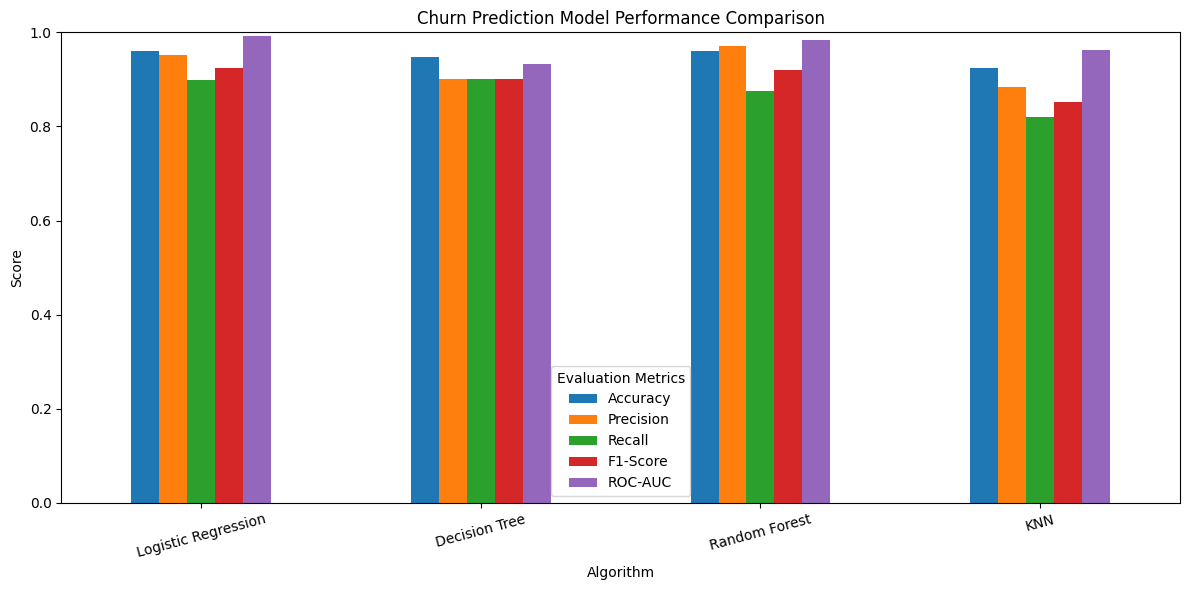

In [ ]:
# Import matplotlib for creating the chart
import matplotlib.pyplot as plt

# Set the algorithm names as the index
chart_data = model_comparison.set_index("Algorithm")

# Create a bar chart for all evaluation metrics
chart_data.plot(
    kind="bar",
    figsize=(12, 6)
)

# Add a title to the chart
plt.title("Churn Prediction Model Performance Comparison")

# Label the X-axis
plt.xlabel("Algorithm")

# Label the Y-axis
plt.ylabel("Score")

# Keep the score range between 0 and 1
plt.ylim(0, 1)

# Rotate algorithm names slightly for readability
plt.xticks(rotation=15)

# Display the legend
plt.legend(
    title="Evaluation Metrics"
)

# Adjust spacing
plt.tight_layout()

# Display the chart
plt.show()

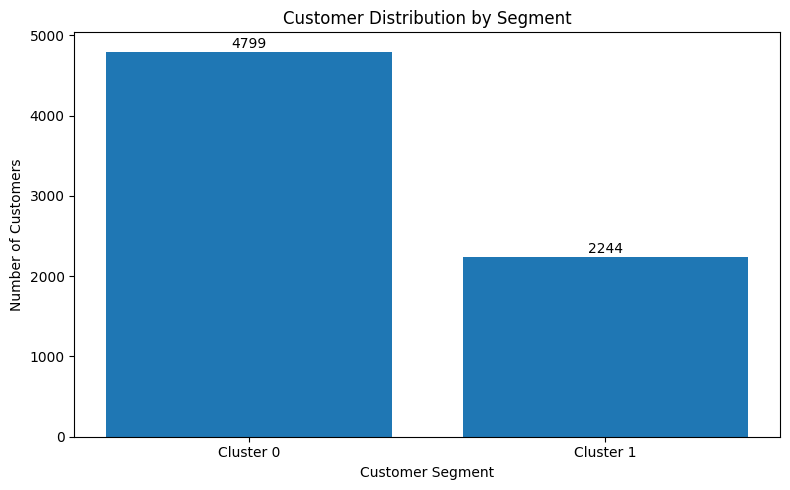

In [ ]:

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Count the number of customers in each cluster
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()

# Create the bar chart
plt.figure(figsize=(8, 5))

# Plot the number of customers in each cluster
plt.bar(
    ["Cluster 0", "Cluster 1"],
    cluster_counts.values
)

# Add chart title
plt.title("Customer Distribution by Segment")

# Label the X-axis
plt.xlabel("Customer Segment")

# Label the Y-axis
plt.ylabel("Number of Customers")

# Display the exact customer count above each bar
for i, value in enumerate(cluster_counts.values):
    plt.text(
        i,
        value + 50,
        str(value),
        ha="center"
    )

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

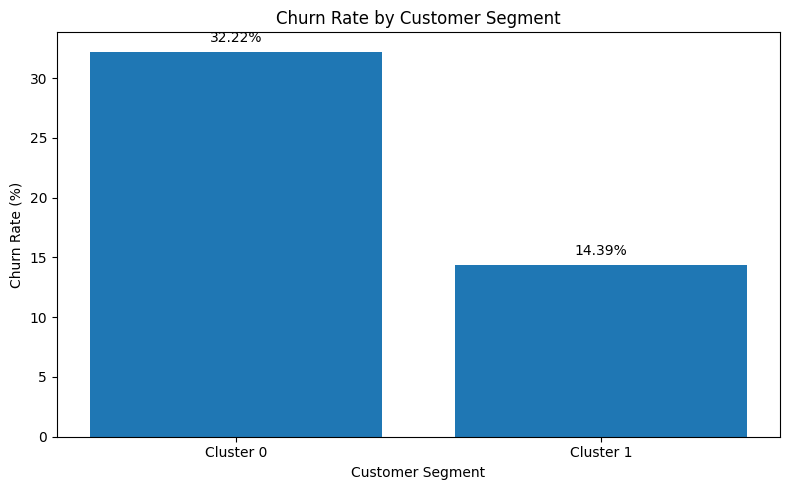

In [ ]:

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Get the churn rates from our summary table
churn_rates = cluster_churn_summary["Churn_Rate"]

# Create the bar chart
plt.figure(figsize=(8, 5))

# Plot churn rate for each customer segment
plt.bar(
    ["Cluster 0", "Cluster 1"],
    churn_rates.values
)

# Add chart title
plt.title("Churn Rate by Customer Segment")

# Label the X-axis
plt.xlabel("Customer Segment")

# Label the Y-axis
plt.ylabel("Churn Rate (%)")

# Display the exact churn percentage above each bar
for i, value in enumerate(churn_rates.values):
    plt.text(
        i,
        value + 0.8,
        f"{value:.2f}%",
        ha="center"
    )

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

In [ ]:

# Import PCA
from sklearn.decomposition import PCA

# Create PCA with 2 components
# This reduces our 11 features into 2 dimensions
# so that we can visualize the clusters.
pca = PCA(n_components=2)

# Transform the standardized segmentation data
X_pca = pca.fit_transform(
    X_segmentation_scaled
)

# Display the new shape
print("PCA data shape:", X_pca.shape)

PCA data shape: (7043, 2)


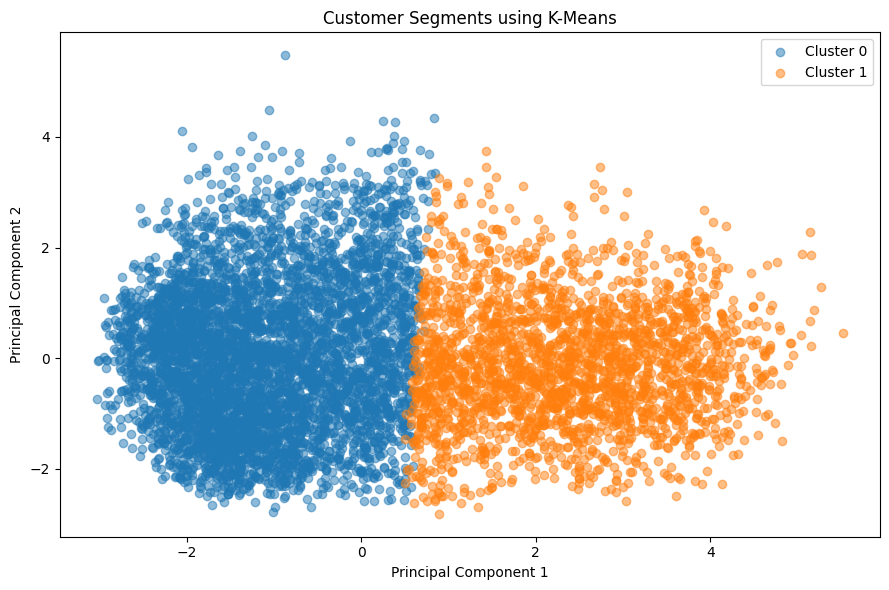

In [ ]:

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Create a figure for the scatter plot
plt.figure(figsize=(9, 6))

# Plot customers belonging to Cluster 0
plt.scatter(
    X_pca[cluster_labels == 0, 0],
    X_pca[cluster_labels == 0, 1],
    label="Cluster 0",
    alpha=0.5
)

# Plot customers belonging to Cluster 1
plt.scatter(
    X_pca[cluster_labels == 1, 0],
    X_pca[cluster_labels == 1, 1],
    label="Cluster 1",
    alpha=0.5
)

# Add the chart title
plt.title("Customer Segments using K-Means")

# Label the X-axis
plt.xlabel("Principal Component 1")

# Label the Y-axis
plt.ylabel("Principal Component 2")

# Display the legend
plt.legend()

# Adjust spacing
plt.tight_layout()

# Display the chart
plt.show()

In [ ]:

# Display all features currently used for churn prediction
print("Features used for churn prediction:")
print()

for i, column in enumerate(X.columns, start=1):
    print(i, ".", column)

Features used for churn prediction:

1 . Gender
2 . Age
3 . Under 30
4 . Senior Citizen
5 . Married
6 . Dependents
7 . Number of Dependents
8 . Population
9 . Referred a Friend
10 . Number of Referrals
11 . Tenure in Months
12 . Offer
13 . Phone Service
14 . Avg Monthly Long Distance Charges
15 . Multiple Lines
16 . Internet Service
17 . Internet Type
18 . Avg Monthly GB Download
19 . Online Security
20 . Online Backup
21 . Device Protection Plan
22 . Premium Tech Support
23 . Streaming TV
24 . Streaming Movies
25 . Streaming Music
26 . Unlimited Data
27 . Contract
28 . Paperless Billing
29 . Payment Method
30 . Monthly Charge
31 . Total Charges
32 . Total Refunds
33 . Total Extra Data Charges
34 . Total Long Distance Charges
35 . Total Revenue
36 . Satisfaction Score
37 . CLTV


In [ ]:

# Get the names of all features after preprocessing.
# One-hot encoding creates additional columns for categorical features.
feature_names = preprocessor.get_feature_names_out()

# Get the coefficients learned by Logistic Regression.
coefficients = logistic_model.coef_[0]

# Create a DataFrame containing the feature names
# and their corresponding coefficients.
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Calculate the absolute coefficient.
# A larger absolute value means a stronger influence
# on the model's prediction.
feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

# Sort features from strongest to weakest influence.
feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

# Display the 20 most influential features.
display(
    feature_importance.head(20).round(4)
)

,Feature,Coefficient,Absolute_Coefficient
13,num__Satisfaction Score,-6.8900,6.8900
3,num__Number of Referrals,-1.8831,1.8831
44,cat__Online Security_Yes,-1.5532,1.5532
24,cat__Dependents_Yes,-1.3280,1.3280
28,cat__Offer_Offer A,1.1896,1.1896
43,cat__Online Security_No,1.1123,1.1123
61,cat__Contract_Two Year,-1.0937,1.0937
23,cat__Dependents_No,0.8871,0.8871
25,cat__Referred a Friend_No,-0.8690,0.8690
31,cat__Offer_Offer D,-0.8421,0.8421


In [ ]:

# Create a temporary DataFrame containing
# satisfaction score and the churn label.
satisfaction_churn = df_model[
    ["Satisfaction Score", "Churn Label"]
].copy()

# Group customers by satisfaction score
# and calculate their churn rate.
satisfaction_summary = satisfaction_churn.groupby(
    "Satisfaction Score"
)["Churn Label"].apply(
    lambda x: (x == "Yes").mean() * 100
)

# Display the churn rate for each satisfaction score.
print("Churn Rate by Satisfaction Score:")
display(satisfaction_summary.round(2))

Churn Rate by Satisfaction Score:


,Churn Label
Satisfaction Score,
1,100.0
2,100.0
3,16.1
4,0.0
5,0.0


In [ ]:

# Create a copy of the current features
# so that the original X remains unchanged.
X_no_satisfaction = X.copy()

# Remove Satisfaction Score
# This allows us to check how much the model depends on it.
X_no_satisfaction = X_no_satisfaction.drop(
    columns=["Satisfaction Score"]
)

# Display the new feature count
print(
    "Features after removing Satisfaction Score:",
    X_no_satisfaction.shape
)

Features after removing Satisfaction Score: (7043, 36)


In [ ]:
# Create the numerical feature list without Satisfaction Score
numerical_features_no_sat = [
    feature
    for feature in numerical_features
    if feature != "Satisfaction Score"
]

# Categorical features remain unchanged
categorical_features_no_sat = categorical_features.copy()

# Split the data into training and testing sets
X_train_no_sat, X_test_no_sat, y_train_no_sat, y_test_no_sat = train_test_split(
    X_no_satisfaction,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create preprocessing pipeline for the new feature set
preprocessor_no_sat = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features_no_sat),
        ("cat", OneHotEncoder(handle_unknown="ignore"),
         categorical_features_no_sat)
    ]
)

# Preprocess training data
X_train_no_sat_processed = preprocessor_no_sat.fit_transform(
    X_train_no_sat
)

# Preprocess testing data
X_test_no_sat_processed = preprocessor_no_sat.transform(
    X_test_no_sat
)

# Create Logistic Regression model
logistic_no_sat = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_no_sat.fit(
    X_train_no_sat_processed,
    y_train_no_sat
)

print("Logistic Regression without Satisfaction Score trained successfully!")

Logistic Regression without Satisfaction Score trained successfully!


In [ ]:

# Make predictions on the test data
y_pred_no_sat = logistic_no_sat.predict(
    X_test_no_sat_processed
)

# Get churn probabilities
y_probability_no_sat = logistic_no_sat.predict_proba(
    X_test_no_sat_processed
)[:, 1]

# Calculate all evaluation metrics
accuracy_no_sat = accuracy_score(
    y_test_no_sat,
    y_pred_no_sat
)

precision_no_sat = precision_score(
    y_test_no_sat,
    y_pred_no_sat
)

recall_no_sat = recall_score(
    y_test_no_sat,
    y_pred_no_sat
)

f1_no_sat = f1_score(
    y_test_no_sat,
    y_pred_no_sat
)

roc_auc_no_sat = roc_auc_score(
    y_test_no_sat,
    y_probability_no_sat
)

# Display the results
print("Logistic Regression Without Satisfaction Score")
print("-----------------------------------------------")
print("Accuracy :", round(accuracy_no_sat, 4))
print("Precision:", round(precision_no_sat, 4))
print("Recall   :", round(recall_no_sat, 4))
print("F1-Score :", round(f1_no_sat, 4))
print("ROC-AUC  :", round(roc_auc_no_sat, 4))

Logistic Regression Without Satisfaction Score
-----------------------------------------------
Accuracy : 0.8502
Precision: 0.739
Recall   : 0.6738
F1-Score : 0.7049
ROC-AUC  : 0.91


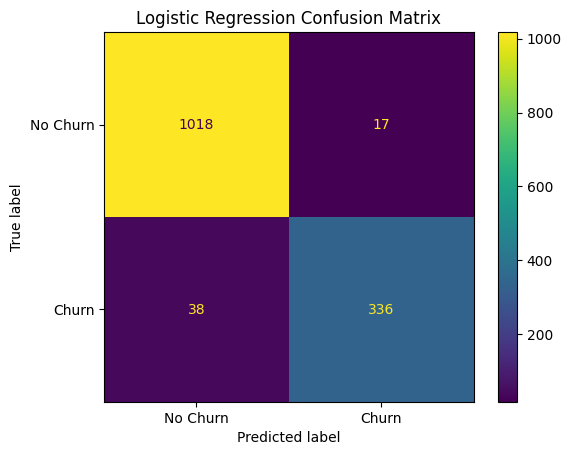

In [ ]:

# Import the confusion matrix display tool
from sklearn.metrics import ConfusionMatrixDisplay

# Create the confusion matrix visualization
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Churn", "Churn"]
)

# Add a title
plt.title("Logistic Regression Confusion Matrix")

# Display the chart
plt.show()

In [ ]:

# Select the first customer from the original feature dataset
# and convert it into a DataFrame containing one row.
sample_customer = X.iloc[[0]].copy()

# Display the customer's input data
print("Sample Customer:")
display(sample_customer)

Sample Customer:


,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Population,Referred a Friend,Number of Referrals,...,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,CLTV
0,Male,78,No,Yes,No,No,0,68701,No,0,...,Yes,Bank Withdrawal,39.65,39.65,0.0,20,0.0,59.65,3,5433


In [ ]:

# Preprocess the sample customer using the SAME preprocessing
# pipeline that was fitted during model training.
sample_customer_processed = preprocessor.transform(
    sample_customer
)

# Predict whether this customer will churn.
sample_prediction = logistic_model.predict(
    sample_customer_processed
)[0]

# Get the probability that the customer will churn.
sample_probability = logistic_model.predict_proba(
    sample_customer_processed
)[0][1]

# Convert the numerical prediction into a readable result.
if sample_prediction == 1:
    prediction_result = "Likely to Churn"
else:
    prediction_result = "Not Likely to Churn"

# Display the result
print("Prediction:", prediction_result)
print(
    "Churn Probability:",
    round(sample_probability * 100, 2),
    "%"
)

Prediction: Likely to Churn
Churn Probability: 82.08 %


In [ ]:

# Select the 11 features used for customer segmentation
sample_customer_segmentation = sample_customer[
    segmentation_features
]

# Standardize the customer's segmentation features
# using the SAME scaler that was fitted earlier.
sample_customer_segmentation_scaled = scaler.transform(
    sample_customer_segmentation
)

# Predict which K-Means cluster the customer belongs to
sample_cluster = final_kmeans.predict(
    sample_customer_segmentation_scaled
)[0]

# Display the cluster number
print("Customer Cluster:", sample_cluster)

Customer Cluster: 0


In [ ]:

# Assign a meaningful name to each cluster
if sample_cluster == 0:
    segment_name = "Newer / Lower-Value Customer"
else:
    segment_name = "High-Value / Established Customer"

# Display the customer segment
print("Customer Segment:", segment_name)

Customer Segment: Newer / Lower-Value Customer


In [ ]:

# Create a reusable function for the complete prediction system
def predict_customer(customer_data):

    # -------------------------------
    # 1. Churn Prediction
    # -------------------------------

    # Apply the same preprocessing used during model training
    customer_processed = preprocessor.transform(
        customer_data
    )

    # Predict whether the customer will churn
    churn_prediction = logistic_model.predict(
        customer_processed
    )[0]

    # Get the probability of churn
    churn_probability = logistic_model.predict_proba(
        customer_processed
    )[0][1]

    # Convert 0/1 prediction into readable text
    if churn_prediction == 1:
        churn_result = "Likely to Churn"
    else:
        churn_result = "Not Likely to Churn"


    # -------------------------------
    # 2. Customer Segmentation
    # -------------------------------

    # Select the 11 features used for K-Means
    customer_segmentation = customer_data[
        segmentation_features
    ]

    # Apply the same scaling used during K-Means training
    customer_segmentation_scaled = scaler.transform(
        customer_segmentation
    )

    # Predict the customer's cluster
    cluster = final_kmeans.predict(
        customer_segmentation_scaled
    )[0]

    # Convert cluster number into a meaningful segment name
    if cluster == 0:
        segment = "Newer / Lower-Value Customer"
    else:
        segment = "High-Value / Established Customer"


    # -------------------------------
    # 3. Return the Results
    # -------------------------------

    return {
        "churn_prediction": churn_result,
        "churn_probability": round(
            churn_probability * 100, 2
        ),
        "cluster": int(cluster),
        "segment": segment
    }


# Confirmation message
print("Prediction function created successfully!")

Prediction function created successfully!


In [ ]:

# Test the complete prediction system
result = predict_customer(sample_customer)

# Display the results
print("========================================")
print("       CUSTOMER CHURN PREDICTION")
print("========================================")

print("Churn Prediction    :", result["churn_prediction"])
print("Churn Probability   :", result["churn_probability"], "%")
print("Customer Cluster    :", result["cluster"])
print("Customer Segment    :", result["segment"])

print("========================================")

       CUSTOMER CHURN PREDICTION
Churn Prediction    : Likely to Churn
Churn Probability   : 82.08 %
Customer Cluster    : 0
Customer Segment    : Newer / Lower-Value Customer


In [ ]:
import joblib

# Save all trained models and preprocessing objects
joblib.dump(logistic_model, "logistic_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(final_kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "segmentation_scaler.pkl")

print("All models saved successfully!")

All models saved successfully!


In [ ]:
import joblib

# Store everything required by the application
app_artifacts = {
    "logistic_model": logistic_model,
    "preprocessor": preprocessor,
    "kmeans_model": final_kmeans,
    "scaler": scaler,
    "numerical_features": numerical_features,
    "categorical_features": categorical_features,
    "segmentation_features": segmentation_features
}

joblib.dump(app_artifacts, "customer_churn_artifacts.pkl")

print("Application artifacts saved successfully!")

Application artifacts saved successfully!


In [ ]:
from google.colab import files

files.download("customer_churn_artifacts.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1


In [ ]:
import joblib

churn_artifacts = {
    "model": logistic_model,
    "preprocessor": preprocessor,
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "feature_names": feature_names
}

joblib.dump(
    churn_artifacts,
    "churnguard_churn_artifacts.pkl"
)

print("ChurnGuard artifacts saved successfully!")

ChurnGuard artifacts saved successfully!


In [ ]:
import joblib

artifacts = joblib.load("churnguard_churn_artifacts.pkl")

print(artifacts.keys())
print(type(artifacts["model"]))
print(type(artifacts["preprocessor"]))

dict_keys(['model', 'preprocessor', 'categorical_features', 'numerical_features', 'feature_names'])
<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [ ]:
from google.colab import files

files.download("churnguard_churn_artifacts.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib
import sklearn

print("scikit-learn version:", sklearn.__version__)

artifacts = joblib.load("churnguard_churn_artifacts.pkl")

print("Artifact loaded successfully!")
print(artifacts.keys())

print("Model:", type(artifacts["model"]))
print("Preprocessor:", type(artifacts["preprocessor"]))
print("Categorical features:", artifacts["categorical_features"])
print("Numerical features:", artifacts["numerical_features"])
print("Feature count:", len(artifacts["feature_names"]))

scikit-learn version: 1.6.1
Artifact loaded successfully!
dict_keys(['model', 'preprocessor', 'categorical_features', 'numerical_features', 'feature_names'])
Model: <class 'sklearn.linear_model._logistic.LogisticRegression'>
Preprocessor: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Categorical features: ['Gender', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Referred a Friend', 'Offer', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method']
Numerical features: ['Age', 'Number of Dependents', 'Population', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenu